<h1 style="color:#1398A1">TRAINING<h1>

<h3 style="color:#CCC229">LIBRAIRIES AND DATA LOADING<h3>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

In [5]:
def load_config(model_architecture:str = "fashion_mnist"):
    # Ouverture du fichier
    path = None
    if model_architecture == "fashion_mnist":
        path = "configs/fashion_mnist.yml"
    elif model_architecture == "cifar100":
        path = "configs/cifar100.yml"
    else:
        raise AssertionError("Modèle d'architecture incompatible. Choisissez 'fashion_mnist' ou 'cifar100'")

    with open(path, "r") as file:
        # Chargement du contenu du fichier
        config = yaml.safe_load(file)
        return config["dataset"], config["training"], config["models"]

In [6]:
dataset_config, training_config, models_config = load_config("fashion_mnist")

In [7]:
import torch
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn.functional as F

dataset = MNIST(root = 'data/', download = True)

Label: 3


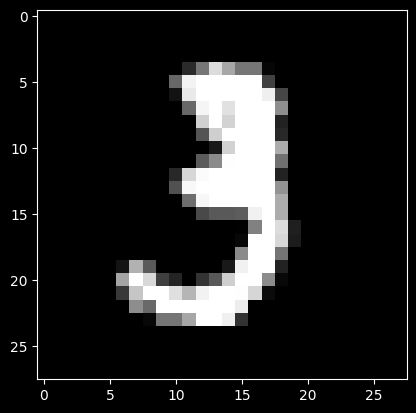

In [8]:
image, label = dataset[10]
plt.imshow(image, cmap = 'gray')
print('Label:', label)

In [9]:
mnist_dataset = MNIST(root = 'data/', train = True, transform = transforms.ToTensor())
print(mnist_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()


In [10]:
image_tensor, label = mnist_dataset[0]
print(image_tensor.shape, label)

torch.Size([1, 28, 28]) 5


In [11]:
train_data, validation_data = random_split(mnist_dataset, [50000, 10000])
print("length of Train Datasets: ", len(train_data))
print("length of Validation Datasets: ", len(validation_data))

length of Train Datasets:  50000
length of Validation Datasets:  10000


In [12]:
dataset_config

{'name': 'fashion_mnist', 'input_shape': [1, 28, 28], 'num_classes': 10}

In [13]:
training_config

{'batch_size': 64,
 'epochs': 3,
 'learning_rate': 0.001,
 'validation_split': 0.2,
 'shuffle': True,
 'random_seed': 42,
 'optimizer': {'type': 'Adam', 'learning_rate': 0.001}}

In [14]:
models_config

{'mlp_v1': {'description': 'architecture multi-layer perceptron simple',
  'architecture': {'type': 'MLP',
   'layers': [{'type': 'Flatten'},
    {'type': 'Dense', 'units': 128, 'activation': 'relu'},
    {'type': 'dense', 'units': 10, 'activation': 'softmax'}]}}}

In [15]:
train_loader = DataLoader(train_data, training_config["batch_size"], training_config["shuffle"])
val_loader = DataLoader(validation_data, training_config["batch_size"], training_config["shuffle"])

In [16]:
def create_mlp(config):
    model = models.Sequential()
    for layer_cfg in config['layers']:
        l_type = layer_cfg['type'].lower()
        if l_type == 'flatten':
            model.add(layers.Flatten(input_shape=dataset_config['input_shape']))
        elif l_type == 'dense':
            model.add(layers.Dense(
                units=layer_cfg['units'],
                activation=layer_cfg['activation']
            ))
    return model

with tf.device('/CPU:0'):
    model = create_mlp(models_config['mlp_v1']['architecture'])
    optimizer_type = training_config['optimizer']['type']
    lr = training_config['optimizer']['learning_rate']

    if optimizer_type == 'Adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

/home/cytech/programmation/AI/ai_cytech_cours/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
def torch_to_tf_generator(loader):
    for images, labels in loader:
        yield images.numpy(), labels.numpy()

train_dataset = tf.data.Dataset.from_generator(
    lambda: torch_to_tf_generator(train_loader),
    output_signature=(
        tf.TensorSpec(shape=(None, 1, 28, 28), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int64)
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: torch_to_tf_generator(val_loader),
    output_signature=(
        tf.TensorSpec(shape=(None, 1, 28, 28), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int64)
    )
)

with tf.device('/CPU:0'):
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=training_config['epochs'],
        steps_per_epoch=len(train_loader),
        validation_steps=len(val_loader)
    )

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9083 - loss: 0.3272 - val_accuracy: 0.9453 - val_loss: 0.1963
Epoch 2/3


2026-03-08 21:05:00.243198: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/cytech/programmation/AI/ai_cytech_cours/deep_learning/.venv/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9453 - val_loss: 0.1963
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9539 - loss: 0.1592 - val_accuracy: 0.9589 - val_loss: 0.1335
